## RFUAV Experiment 5 — Noisy Drone RF Signal Classification with ResNet18

This notebook is a cleaned Colab workflow for the **Kaggle Noisy Drone RF Signal Classification** dataset.

Main goals:

1. Check GPU, RAM, and disk space.
2. Download the Kaggle dataset safely.
3. Load the large `dataset.pt` file with `mmap=True` so Colab RAM does not crash.
4. Create a balanced 7-class subset.
5. Train a **ResNet18 model modified for 2-channel RF spectrogram tensors**.
6. Evaluate with a classification report, confusion matrix, and accuracy-by-SNR plot.

The dataset provides both raw IQ and spectrogram tensors. This notebook uses:

```text
x_spec: [number_of_samples, 2, 128, 128]
```






## 1. Check GPU, RAM, and disk

Use this first to confirm whether Colab has a GPU and enough disk/RAM.


In [14]:
import os
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. Go to Runtime → Change runtime type → GPU.")

print("\nRAM:")
!free -h

print("\nDisk:")
!df -h /content


CUDA available: True
GPU: Tesla T4

RAM:
               total        used        free      shared  buff/cache   available
Mem:            12Gi       2.4Gi       186Mi        40Mi        10Gi       9.9Gi
Swap:             0B          0B          0B

Disk:
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   72G   42G  64% /


## 2. Install Kaggle package

The `!` symbol runs a Linux shell command inside Colab.


In [2]:
!pip install -q kaggle


## 3. Set up Kaggle credentials safely

Run this cell and paste your Kaggle username and API key when prompted.

Do **not** write your key directly into the notebook.


In [15]:
import os
import getpass

os.environ["KAGGLE_USERNAME"] = input("Kaggle username: ")
os.environ["KAGGLE_KEY"] = getpass.getpass("Kaggle API key: ")

print("Kaggle credentials set for this Colab session only.")


Kaggle username: tunganhnguyen25
Kaggle API key: ··········
Kaggle credentials set for this Colab session only.


## 4. Test Kaggle access


In [16]:
!kaggle datasets list -s "noisy drone rf signal classification"


ref                                                     title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------  ---------------------------------------------  ------------  --------------------------  -------------  ---------  ---------------  
sgluege/noisy-drone-rf-signal-classification            Noisy Drone RF Signal Classification            23481212016  2023-06-08 11:41:26.823000           1380         15  0.88235295       
sgluege/noisy-drone-rf-signal-classification-v2         Noisy Drone RF Signal Classification v2        124950870773  2024-06-26 09:36:14.370000           5897          9  0.8125           
nivashne/kalman-based-leo-rf-dataset-for-uav-detection  Kalman-Based LEO RF Dataset for UAV Detection       1551916  2026-03-25 15:44:52.707000             17          1  0.5294118        
cengizhanyapcolu/dronerfattack-dataset                 

## 5. Download the smaller Noisy Drone RF dataset

This dataset is about 25 GB after extraction. Do not use the larger v2 dataset yet.


In [1]:
!rm -rf /content/noisy_drone_rf
!mkdir -p /content/noisy_drone_rf

!kaggle datasets download \
  -d sgluege/noisy-drone-rf-signal-classification \
  -p /content/noisy_drone_rf \
  --unzip \
  --force

!rm -f /content/noisy_drone_rf/noisy-drone-rf-signal-classification.zip

!ls -lh /content/noisy_drone_rf

import torch
import os

path = "/content/noisy_drone_rf/dataset.pt"

print("File size GB:", os.path.getsize(path) / 1024**3)

data = torch.load(
    path,
    map_location="cpu",
    mmap=True,
    weights_only=False
)

print("Loaded successfully")
print(data.keys())

Dataset URL: https://www.kaggle.com/datasets/sgluege/noisy-drone-rf-signal-classification
License(s): Attribution 4.0 International (CC BY 4.0)
100% 21.9G/21.9G [04:11<00:00, 93.3MB/s]

total 25G
-rw-r--r-- 1 root root 143 Jun  9 06:38 class_stats.csv
-rw-r--r-- 1 root root 25G Jun  9 06:44 dataset.pt
-rw-r--r-- 1 root root 288 Jun  9 06:38 SNR_stats.csv
File size GB: 24.099373045377433
Loaded successfully
dict_keys(['x_iq', 'x_spec', 'y', 'snr', 'duty_cycle'])


In [24]:
import torch
import os

path = "/content/noisy_drone_rf/dataset.pt"

print("Before loading:")
!free -h

try:
    data = torch.load(
        path,
        map_location="cpu",
        mmap=True,
        weights_only=False
    )

    print("Loaded successfully with mmap")
    print("Type:", type(data))

    if isinstance(data, dict):
        print("Keys:")
        for k, v in data.items():
            print(k, type(v), getattr(v, "shape", None), getattr(v, "dtype", None))

    elif isinstance(data, (list, tuple)):
        print("Length:", len(data))
        for i, item in enumerate(data[:5]):
            print(i, type(item), getattr(item, "shape", None), getattr(item, "dtype", None))

    else:
        print(data)

except Exception as e:
    print("Failed to load safely:")
    print(type(e).__name__, e)

print("After loading attempt:")
!free -h

Before loading:
               total        used        free      shared  buff/cache   available
Mem:            12Gi       2.4Gi       172Mi        40Mi        10Gi       9.9Gi
Swap:             0B          0B          0B
Loaded successfully with mmap
Type: <class 'dict'>
Keys:
x_iq <class 'torch.Tensor'> torch.Size([98705, 2, 16384]) torch.float32
x_spec <class 'torch.Tensor'> torch.Size([98705, 2, 128, 128]) torch.float32
y <class 'torch.Tensor'> torch.Size([98705]) torch.int64
snr <class 'torch.Tensor'> torch.Size([98705]) torch.int32
duty_cycle <class 'torch.Tensor'> torch.Size([98705]) torch.float32
After loading attempt:
               total        used        free      shared  buff/cache   available
Mem:            12Gi       2.4Gi       172Mi        40Mi        10Gi       9.9Gi
Swap:             0B          0B          0B


## 6. Inspect class and SNR statistics

This shows the class imbalance and SNR distribution.


In [39]:
import pandas as pd

class_stats_path = "/content/noisy_drone_rf/class_stats.csv"
snr_stats_path = "/content/noisy_drone_rf/SNR_stats.csv"

class_stats = pd.read_csv(class_stats_path)
snr_stats = pd.read_csv(snr_stats_path)

print("Class stats:")
display(class_stats)

print("SNR stats:")
display(snr_stats)


Class stats:


,Unnamed: 0,class,class_int,count
0,0,DJI,0,2194
1,1,FutabaT14,1,6938
2,2,FutabaT7,2,3661
3,3,Graupner,3,6481
4,4,Noise,4,52552
5,5,Taranis,5,16546
6,6,Turnigy,6,10333


SNR stats:


,Unnamed: 0,SNR,count
0,0,-20,3792
1,1,-18,3795
2,2,-16,3796
3,3,-14,3796
4,4,-12,3797
5,5,-10,3796
6,6,-8,3795
7,7,-6,3795
8,8,-4,3798
9,9,-2,3798


## 7. Safely load `dataset.pt` with memory mapping

`dataset.pt` is around 24–25 GB, so normal `torch.load()` can crash Colab RAM.

Always use:

```python
torch.load(path, map_location="cpu", mmap=True, weights_only=False)
```


In [18]:
import torch
import os

path = "/content/noisy_drone_rf/dataset.pt"
print("File size GB:", os.path.getsize(path) / 1024**3)

print("Before loading:")
!free -h

data = torch.load(
    path,
    map_location="cpu",
    mmap=True,
    weights_only=False
)

print("Loaded successfully with mmap")
print("Type:", type(data))

for k, v in data.items():
    print(k, type(v), getattr(v, "shape", None), getattr(v, "dtype", None))

print("After loading:")
!free -h


File size GB: 24.099373045377433
Before loading:
               total        used        free      shared  buff/cache   available
Mem:            12Gi       2.4Gi       196Mi        40Mi        10Gi       9.9Gi
Swap:             0B          0B          0B
Loaded successfully with mmap
Type: <class 'dict'>
x_iq <class 'torch.Tensor'> torch.Size([98705, 2, 16384]) torch.float32
x_spec <class 'torch.Tensor'> torch.Size([98705, 2, 128, 128]) torch.float32
y <class 'torch.Tensor'> torch.Size([98705]) torch.int64
snr <class 'torch.Tensor'> torch.Size([98705]) torch.int32
duty_cycle <class 'torch.Tensor'> torch.Size([98705]) torch.float32
After loading:
               total        used        free      shared  buff/cache   available
Mem:            12Gi       2.4Gi       196Mi        40Mi        10Gi       9.9Gi
Swap:             0B          0B          0B


## 8. Create a balanced 7-class subset

The full dataset is imbalanced because the `Noise` class is much larger than the smallest class.

For a fair first experiment, use:

- 1700 training samples per class
- 400 validation samples per class
- 7 classes total

In [29]:
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

class_names = [
    "DJI",
    "FutabaT14",
    "FutabaT7",
    "Graupner",
    "Noise",
    "Taranis",
    "Turnigy"
]

y = data["y"]

train_per_class = 1700
valid_per_class = 400

train_indices = []
valid_indices = []

for cls, name in enumerate(class_names):
    cls_indices = torch.where(y == cls)[0].cpu().numpy()
    np.random.shuffle(cls_indices)

    needed = train_per_class + valid_per_class
    if len(cls_indices) < needed:
        raise ValueError(f"Class {name} has only {len(cls_indices)} samples, but {needed} are needed.")

    train_indices.extend(cls_indices[:train_per_class])
    valid_indices.extend(cls_indices[train_per_class:train_per_class + valid_per_class])

train_indices = np.array(train_indices)
valid_indices = np.array(valid_indices)

np.random.shuffle(train_indices)
np.random.shuffle(valid_indices)

print("Train samples:", len(train_indices))
print("Valid samples:", len(valid_indices))

for cls, name in enumerate(class_names):
    train_count = int((y[train_indices] == cls).sum().item())
    valid_count = int((y[valid_indices] == cls).sum().item())
    print(f"{name}: train={train_count}, valid={valid_count}")


Train samples: 11900
Valid samples: 2800
DJI: train=1700, valid=400
FutabaT14: train=1700, valid=400
FutabaT7: train=1700, valid=400
Graupner: train=1700, valid=400
Noise: train=1700, valid=400
Taranis: train=1700, valid=400
Turnigy: train=1700, valid=400


## 9. Build a PyTorch Dataset and DataLoader for `x_spec`

`x_spec` has shape:

```text
[number_of_samples, 2, 128, 128]
```

So the CNN input channel count must be `2`.


In [30]:
from torch.utils.data import Dataset, DataLoader

class NoisyDroneSpecDataset(Dataset):
    def __init__(self, data, indices):
        self.x_spec = data["x_spec"]
        self.y = data["y"]
        self.snr = data["snr"]
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = int(self.indices[idx])
        x = self.x_spec[real_idx]   # [2, 128, 128]
        label = self.y[real_idx]
        snr = self.snr[real_idx]
        return x, label, snr

batch_size = 64
num_workers = 0  # Safer for Colab + memory-mapped tensors
pin_memory = torch.cuda.is_available()

train_dataset = NoisyDroneSpecDataset(data, train_indices)
valid_dataset = NoisyDroneSpecDataset(data, valid_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

x_batch, y_batch, snr_batch = next(iter(train_loader))
print("x batch:", x_batch.shape)
print("y batch:", y_batch.shape)
print("snr batch:", snr_batch.shape)
print("x dtype:", x_batch.dtype)
print("y dtype:", y_batch.dtype)
print("snr dtype:", snr_batch.dtype)


x batch: torch.Size([64, 2, 128, 128])
y batch: torch.Size([64])
snr batch: torch.Size([64])
x dtype: torch.float32
y dtype: torch.int64
snr dtype: torch.int32


## 10. Define ResNet18 for 2-channel RF spectrograms

Normal ResNet18 expects RGB images with shape:

```text
[batch, 3, height, width]
```

This dataset uses RF spectrogram tensors with shape:

```text
[batch, 2, 128, 128]
```

So we modify the first convolution layer to accept 2 input channels and change the final fully connected layer to output 7 classes.

For this RF dataset, we use `weights=None` because ImageNet pretrained weights are designed for natural RGB images, not 2-channel RF spectrograms.


In [31]:
import torch.nn as nn
from torchvision import models

class ResNet18RFSpec(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        # Start with a standard ResNet18 architecture.
        # weights=None avoids RGB ImageNet pretrained weights.
        self.model = models.resnet18(weights=None)

        # Original ResNet18 first layer expects 3-channel RGB images.
        # Our RF spectrogram tensors have 2 channels, so change 3 -> 2.
        self.model.conv1 = nn.Conv2d(
            in_channels=2,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        # Replace the final classifier for 7 drone/noise classes.
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

# Quick shape test before training.
model_test = ResNet18RFSpec(num_classes=7)
with torch.no_grad():
    out = model_test(x_batch[:2])
print("Test output shape:", out.shape)


Test output shape: torch.Size([2, 7])


## 11. Mount Google Drive for saving results

This cell is optional but recommended. If Drive is not mounted, results are saved in `/content/noisy_drone_results`.


In [40]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = "/content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced"
except Exception as e:
    print("Drive mount failed or not available:", e)
    SAVE_DIR = "/content/noisy_drone_results/noisy_drone_resnet18_spec_balanced"

os.makedirs(SAVE_DIR, exist_ok=True)
print("Save directory:", SAVE_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save directory: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced


## 12. Train ResNet18

This trains ResNet18 on the balanced spectrogram subset and saves:

- `best.pt`
- `last.pt`
- `history.csv`

Start with `batch_size = 64`. If Colab gives a CUDA out-of-memory error, go back to the DataLoader cell and reduce `batch_size` to `32`.


In [33]:
import torch.optim as optim
from tqdm import tqdm
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ResNet18RFSpec(num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20  # You can reduce to 10 for a faster first test
history = []
best_acc = 0.0

for epoch in range(epochs):
    print("=" * 60)
    print(f"Epoch {epoch + 1}/{epochs}")

    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x, labels, snrs in tqdm(train_loader, desc="Training"):
        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()
    valid_loss = 0.0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():
        for x, labels, snrs in tqdm(valid_loader, desc="Validation"):
            x = x.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(x)
            loss = criterion(outputs, labels)

            valid_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)
            valid_correct += (preds == labels).sum().item()
            valid_total += labels.size(0)

    valid_loss /= valid_total
    valid_acc = valid_correct / valid_total

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}")
    print(f"Valid Acc : {valid_acc:.4f}")

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc,
    })

    if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, "best.pt"))
        print("Saved best model.")

torch.save(model.state_dict(), os.path.join(SAVE_DIR, "last.pt"))
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(SAVE_DIR, "history.csv"), index=False)

print("Finished.")
print("Best valid accuracy:", best_acc)
print("Saved to:", SAVE_DIR)


Using device: cuda
Epoch 1/20


Validation: 100%|██████████| 44/44 [00:02<00:00, 18.90it/s]


Train Loss: 1.4667
Train Acc : 0.4449
Valid Loss: 1.1111
Valid Acc : 0.6125
Saved best model.
Epoch 2/20


Validation: 100%|██████████| 44/44 [00:00<00:00, 47.14it/s]


Train Loss: 0.8343
Train Acc : 0.7021
Valid Loss: 0.7976
Valid Acc : 0.7232
Saved best model.
Epoch 3/20


...

Train Loss: 0.0517
Train Acc : 0.9826
Valid Loss: 0.7195
Valid Acc : 0.8321
Epoch 19/20


Validation: 100%|██████████| 44/44 [00:00<00:00, 47.33it/s]


Train Loss: 0.0513
Train Acc : 0.9828
Valid Loss: 0.8115
Valid Acc : 0.8364
Epoch 20/20


Validation: 100%|██████████| 44/44 [00:00<00:00, 46.83it/s]


Train Loss: 0.0464
Train Acc : 0.9859
Valid Loss: 0.8982
Valid Acc : 0.8382
Finished.
Best valid accuracy: 0.8425
Saved to: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced


## 13. Plot training curves


,epoch,train_loss,train_acc,valid_loss,valid_acc
0,1,1.466659,0.444874,1.111072,0.612500
1,2,0.834267,0.702101,0.797599,0.723214
2,3,0.618043,0.785882,0.684399,0.766786
3,4,0.496022,0.829160,0.541187,0.812857
4,5,0.407466,0.860420,0.694500,0.797857
5,6,0.365536,0.876218,0.486448,0.838571
6,7,0.302956,0.894454,0.505786,0.836071
7,8,0.261732,0.911261,0.569818,0.824286
8,9,0.217513,0.927395,0.606755,0.811429
9,10,0.187973,0.937395,0.584255,0.835357


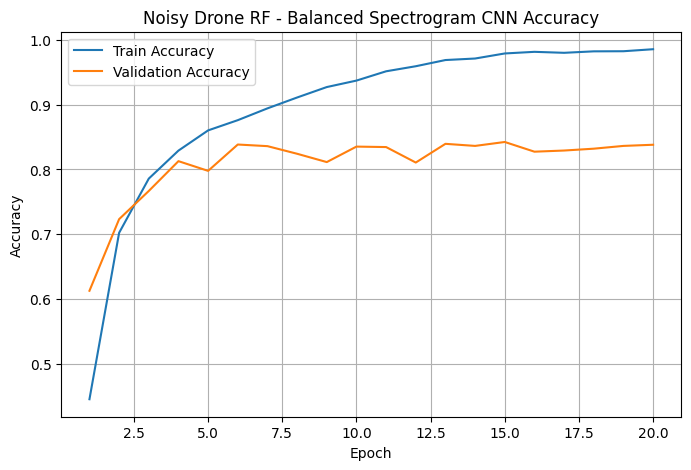

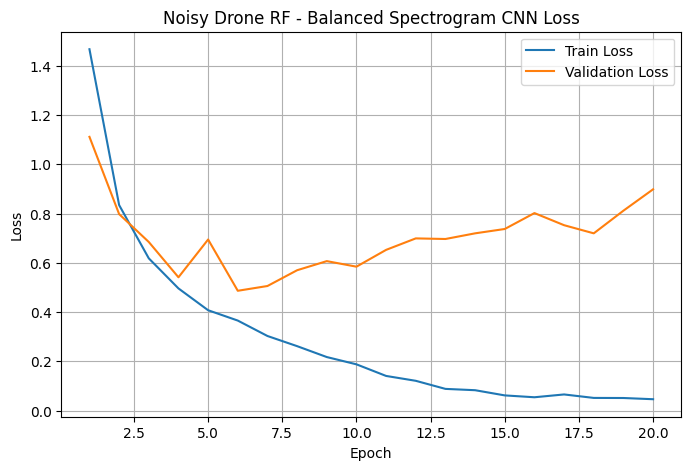

In [34]:
import matplotlib.pyplot as plt

history_path = os.path.join(SAVE_DIR, "history.csv")
history_df = pd.read_csv(history_path)
display(history_df)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["valid_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Noisy Drone RF - Balanced Spectrogram CNN Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["valid_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Noisy Drone RF - Balanced Spectrogram CNN Loss")
plt.legend()
plt.grid(True)
plt.show()


## 14. Classification report and confusion matrix

Use macro F1 because this dataset is naturally imbalanced, even though this first subset is balanced.


Loaded best model: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced/best.pt
              precision    recall  f1-score   support

         DJI       0.95      0.83      0.89       400
   FutabaT14       0.90      0.79      0.84       400
    FutabaT7       0.81      0.85      0.83       400
    Graupner       0.94      0.91      0.92       400
       Noise       0.66      0.82      0.73       400
     Taranis       0.95      0.91      0.93       400
     Turnigy       0.76      0.80      0.78       400

    accuracy                           0.84      2800
   macro avg       0.85      0.84      0.85      2800
weighted avg       0.85      0.84      0.85      2800



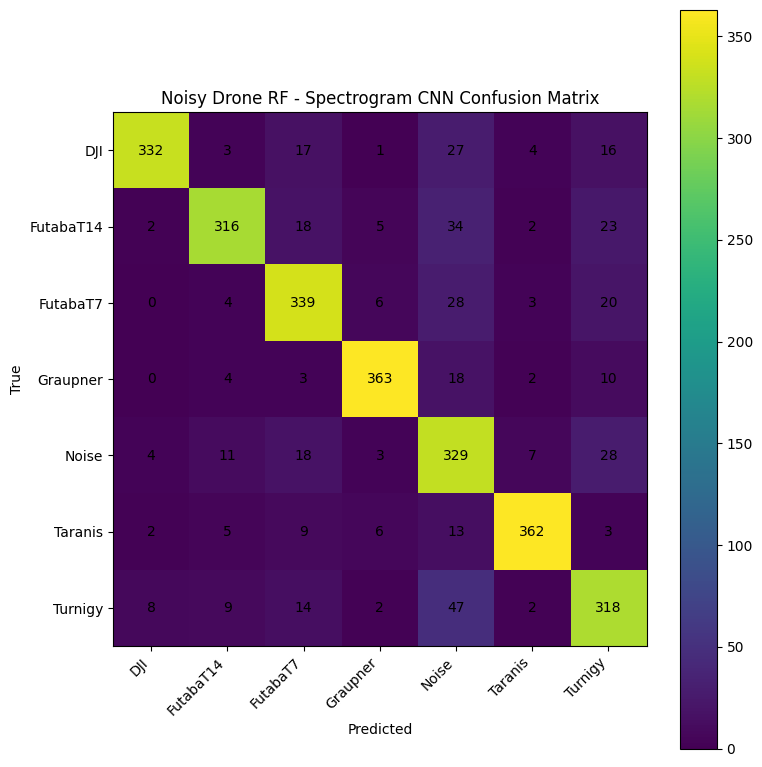

Saved confusion matrix to: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced/confusion_matrix.png


In [38]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load best model before evaluation
best_path = os.path.join(SAVE_DIR, "best.pt")
if os.path.exists(best_path):
    model.load_state_dict(torch.load(best_path, map_location=device))
    print("Loaded best model:", best_path)

model.eval()
all_preds = []
all_labels = []
all_snrs = []

with torch.no_grad():
    for x, labels, snrs in valid_loader:
        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(x)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_snrs.extend(snrs.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("Noisy Drone RF - Spectrogram CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
cm_path = os.path.join(SAVE_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=200)
plt.show()
print("Saved confusion matrix to:", cm_path)


## 15. Accuracy by SNR

This is one of the most important analyses for this dataset.

Low SNR values like `-20 dB` should be harder. High SNR values like `20 dB` to `30 dB` should be easier.


,SNR,accuracy
0,-20,0.224299
1,-18,0.308511
2,-16,0.456311
3,-14,0.587302
4,-12,0.686275
5,-10,0.732558
6,-8,0.855769
7,-6,0.921569
8,-4,0.877551
9,-2,0.926230


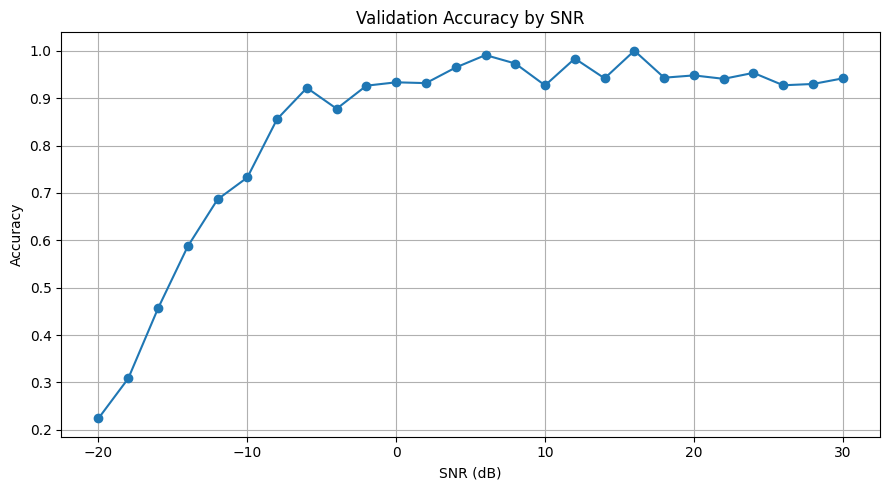

Saved SNR accuracy plot to: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced/accuracy_by_snr.png


In [37]:
results_df = pd.DataFrame({
    "label": all_labels,
    "pred": all_preds,
    "snr": all_snrs,
})
results_df["correct"] = results_df["label"] == results_df["pred"]

snr_acc = results_df.groupby("snr")["correct"].mean().reset_index()
snr_acc.columns = ["SNR", "accuracy"]
display(snr_acc)

plt.figure(figsize=(9, 5))
plt.plot(snr_acc["SNR"], snr_acc["accuracy"], marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy by SNR")
plt.grid(True)
plt.tight_layout()
snr_path = os.path.join(SAVE_DIR, "accuracy_by_snr.png")
plt.savefig(snr_path, dpi=200)
plt.show()
print("Saved SNR accuracy plot to:", snr_path)


## 16. Confusion matrices by SNR group

The overall confusion matrix hides where the model fails. This section splits the validation set into low, medium, and high SNR groups, then creates a separate confusion matrix for each group.

Suggested groups:

```text
Low SNR:    -20 to -10 dB
Medium SNR: -8 to 4 dB
High SNR:    6 to 30 dB
```

This helps show whether errors such as `Turnigy → Noise` mainly happen when the RF signal is weak.


low_snr_-20_to_-10: SNR -20 to -10 dB
Samples: 618
Accuracy: 0.4968

Classification report:
              precision    recall  f1-score   support

         DJI       0.72      0.35      0.47        81
   FutabaT14       0.47      0.23      0.31        88
    FutabaT7       0.45      0.41      0.43        88
    Graupner       0.82      0.61      0.70        87
       Noise       0.32      0.78      0.45        87
     Taranis       0.81      0.63      0.71        86
     Turnigy       0.43      0.48      0.45       101

    accuracy                           0.50       618
   macro avg       0.57      0.50      0.50       618
weighted avg       0.57      0.50      0.50       618



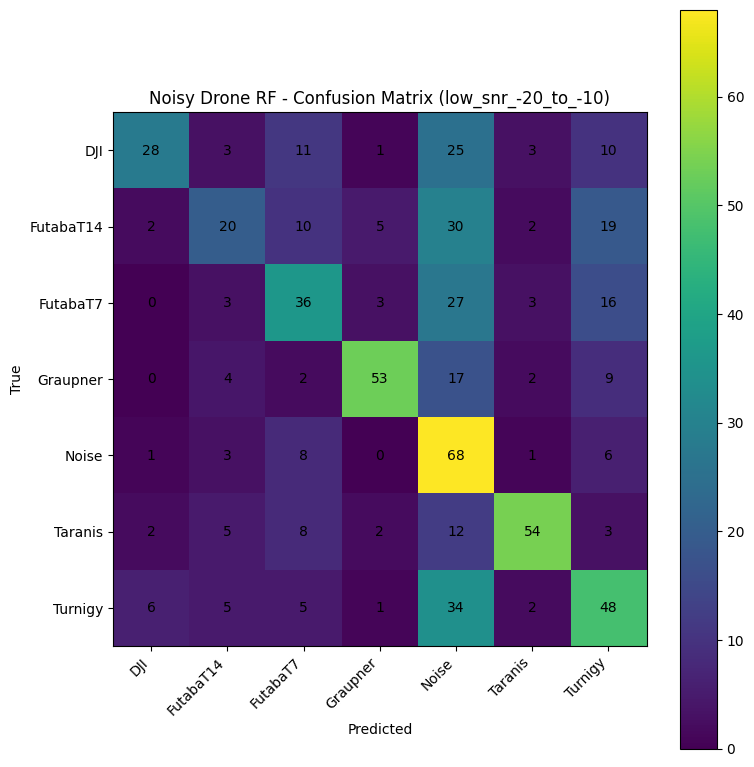

Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced/confusion_matrix_low_snr_-20_to_-10.png
medium_snr_-8_to_4: SNR -8 to 4 dB
Samples: 761
Accuracy: 0.9172

Classification report:
              precision    recall  f1-score   support

         DJI       0.98      0.90      0.94       112
   FutabaT14       0.94      0.88      0.91       112
    FutabaT7       0.85      0.94      0.90       106
    Graupner       0.98      0.99      0.98       119
       Noise       0.85      0.89      0.87       104
     Taranis       0.99      0.97      0.98       111
     Turnigy       0.82      0.81      0.82        97

    accuracy                           0.92       761
   macro avg       0.92      0.91      0.91       761
weighted avg       0.92      0.92      0.92       761



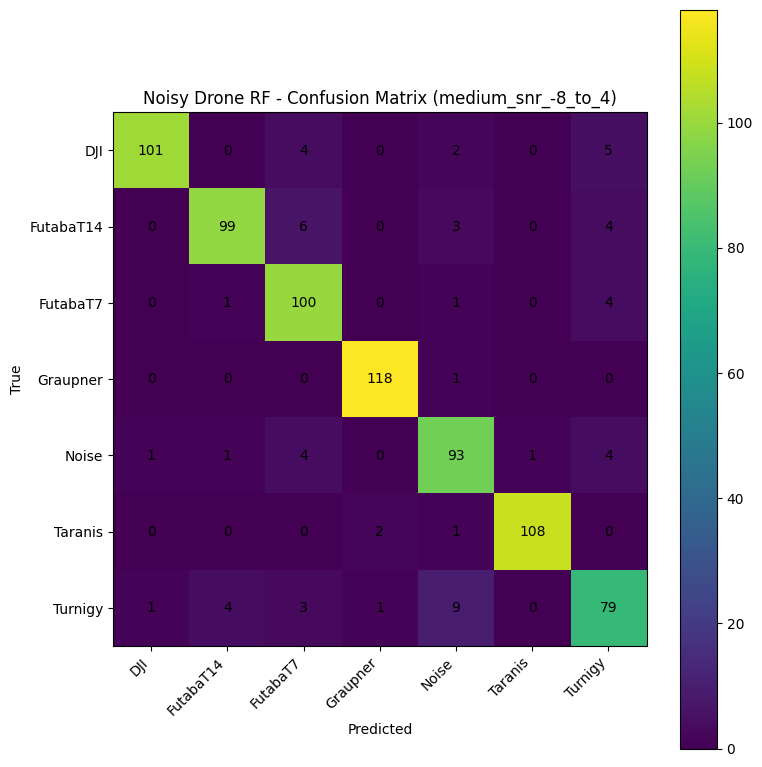

Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced/confusion_matrix_medium_snr_-8_to_4.png
high_snr_6_to_30: SNR 6 to 30 dB
Samples: 1421
Accuracy: 0.9529

Classification report:
              precision    recall  f1-score   support

         DJI       0.99      0.98      0.98       207
   FutabaT14       0.97      0.98      0.98       200
    FutabaT7       0.92      0.99      0.95       206
    Graupner       0.96      0.99      0.97       194
       Noise       0.97      0.80      0.88       209
     Taranis       0.97      0.99      0.98       203
     Turnigy       0.91      0.95      0.92       202

    accuracy                           0.95      1421
   macro avg       0.95      0.95      0.95      1421
weighted avg       0.95      0.95      0.95      1421



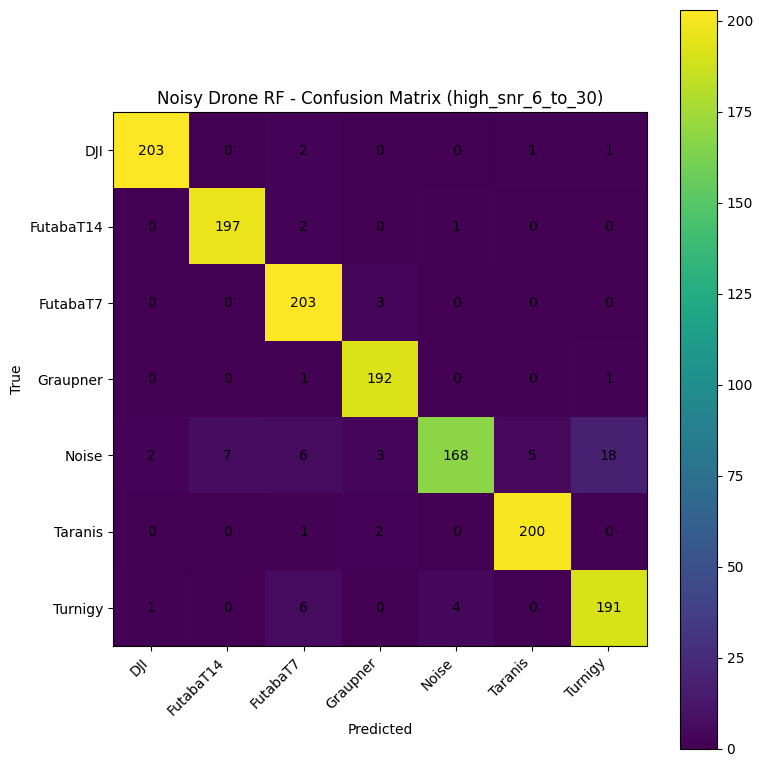

Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced/confusion_matrix_high_snr_6_to_30.png


,group,snr_min,snr_max,samples,accuracy
0,low_snr_-20_to_-10,-20,-10,618,0.496764
1,medium_snr_-8_to_4,-8,4,761,0.917214
2,high_snr_6_to_30,6,30,1421,0.952850


Saved SNR group summary to: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced/snr_group_summary.csv


In [41]:

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# This cell expects these variables from the evaluation cell:
# all_labels, all_preds, all_snrs, class_names, SAVE_DIR

results_df = pd.DataFrame({
    "label": np.array(all_labels),
    "pred": np.array(all_preds),
    "snr": np.array(all_snrs),
})

results_df["correct"] = results_df["label"] == results_df["pred"]

snr_groups = {
    "low_snr_-20_to_-10": (-20, -10),
    "medium_snr_-8_to_4": (-8, 4),
    "high_snr_6_to_30": (6, 30),
}

def plot_confusion_matrix_for_subset(df_subset, title, save_path):
    labels = list(range(len(class_names)))
    cm = confusion_matrix(df_subset["label"], df_subset["pred"], labels=labels)

    plt.figure(figsize=(8, 8))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(np.arange(len(class_names)), class_names)
    plt.colorbar()

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

    return cm

snr_summary_rows = []

for group_name, (snr_min, snr_max) in snr_groups.items():
    subset = results_df[(results_df["snr"] >= snr_min) & (results_df["snr"] <= snr_max)].copy()

    if len(subset) == 0:
        print(f"No validation samples found for {group_name}")
        continue

    acc = subset["correct"].mean()
    print("=" * 80)
    print(f"{group_name}: SNR {snr_min} to {snr_max} dB")
    print(f"Samples: {len(subset)}")
    print(f"Accuracy: {acc:.4f}")

    print("\nClassification report:")
    print(classification_report(
        subset["label"],
        subset["pred"],
        labels=list(range(len(class_names))),
        target_names=class_names,
        zero_division=0,
    ))

    save_path = os.path.join(SAVE_DIR, f"confusion_matrix_{group_name}.png")
    cm_group = plot_confusion_matrix_for_subset(
        subset,
        f"Noisy Drone RF - Confusion Matrix ({group_name})",
        save_path
    )
    print("Saved:", save_path)

    snr_summary_rows.append({
        "group": group_name,
        "snr_min": snr_min,
        "snr_max": snr_max,
        "samples": len(subset),
        "accuracy": acc,
    })

snr_group_summary = pd.DataFrame(snr_summary_rows)
display(snr_group_summary)

summary_path = os.path.join(SAVE_DIR, "snr_group_summary.csv")
snr_group_summary.to_csv(summary_path, index=False)
print("Saved SNR group summary to:", summary_path)


## 17. Per-class recall by SNR group

This table shows which class gets worse when SNR is low. A low recall means many samples from that true class are being predicted as another class, often `Noise`.


In [58]:

# Per-class recall by SNR group
per_class_rows = []

for group_name, (snr_min, snr_max) in snr_groups.items():
    subset = results_df[(results_df["snr"] >= snr_min) & (results_df["snr"] <= snr_max)].copy()

    for cls_id, cls_name in enumerate(class_names):
        cls_subset = subset[subset["label"] == cls_id]

        if len(cls_subset) == 0:
            recall = np.nan
            correct = 0
            total = 0
        else:
            correct = int((cls_subset["pred"] == cls_id).sum())
            total = int(len(cls_subset))
            recall = correct / total

        per_class_rows.append({
            "group": group_name,
            "class": cls_name,
            "correct": correct,
            "total": total,
            "recall": recall,
        })

per_class_snr_recall = pd.DataFrame(per_class_rows)
display(per_class_snr_recall)

per_class_path = os.path.join(SAVE_DIR, "per_class_recall_by_snr_group.csv")
per_class_snr_recall.to_csv(per_class_path, index=False)
print("Saved per-class SNR recall table to:", per_class_path)

# Optional: pivot table for easier reading
pivot_recall = per_class_snr_recall.pivot(index="class", columns="group", values="recall")
display(pivot_recall)


,group,class,correct,total,recall
0,low_snr_-20_to_-10,DJI,28,81,0.345679
1,low_snr_-20_to_-10,FutabaT14,20,88,0.227273
2,low_snr_-20_to_-10,FutabaT7,36,88,0.409091
3,low_snr_-20_to_-10,Graupner,53,87,0.609195
4,low_snr_-20_to_-10,Noise,68,87,0.781609
5,low_snr_-20_to_-10,Taranis,54,86,0.627907
6,low_snr_-20_to_-10,Turnigy,48,101,0.475248
7,medium_snr_-8_to_4,DJI,101,112,0.901786
8,medium_snr_-8_to_4,FutabaT14,99,112,0.883929
9,medium_snr_-8_to_4,FutabaT7,100,106,0.943396


Saved per-class SNR recall table to: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced/per_class_recall_by_snr_group.csv


group,high_snr_6_to_30,low_snr_-20_to_-10,medium_snr_-8_to_4
class,,,
DJI,0.980676,0.345679,0.901786
FutabaT14,0.985000,0.227273,0.883929
FutabaT7,0.985437,0.409091,0.943396
Graupner,0.989691,0.609195,0.991597
Noise,0.803828,0.781609,0.894231
Taranis,0.985222,0.627907,0.972973
Turnigy,0.945545,0.475248,0.814433


## 18. Noise-aware training experiment

The SNR-group confusion matrices showed that most errors happen at **low SNR**. This experiment trains a second ResNet18 model using the same architecture, but changes the training procedure so low-SNR samples matter more.

This notebook uses two noise-aware techniques:

1. **SNR-aware oversampling** using `WeightedRandomSampler`  
   Low-SNR training samples are sampled more often during each epoch.

2. **SNR-weighted loss**  
   Mistakes on low-SNR samples receive a larger loss weight.

The validation set is unchanged, so the result can be compared fairly against the original baseline.


In [66]:
from torch.utils.data import WeightedRandomSampler
import numpy as np
import pandas as pd
import os

# Create a separate save folder so the baseline model is not overwritten.
SAVE_DIR_BASELINE = SAVE_DIR
SAVE_DIR_NOISE_AWARE = SAVE_DIR_BASELINE + "_noise_aware"
os.makedirs(SAVE_DIR_NOISE_AWARE, exist_ok=True)

print("Baseline save directory:", SAVE_DIR_BASELINE)
print("Noise-aware save directory:", SAVE_DIR_NOISE_AWARE)

# Training SNR values for the selected training subset.
train_snrs_np = data["snr"][train_indices].cpu().numpy()

# Define SNR groups. These match the evaluation groups used earlier.
def snr_group_name(snr):
    if -20 <= snr <= -10:
        return "low"
    elif -8 <= snr <= 4:
        return "medium"
    elif 6 <= snr <= 30:
        return "high"
    else:
        return "other"

train_snr_groups = np.array([snr_group_name(float(s)) for s in train_snrs_np])
train_snr_dist = pd.Series(train_snr_groups).value_counts().rename_axis("snr_group").reset_index(name="count")
display(train_snr_dist)

# Oversampling weights: make low SNR appear more often during training.
# You can tune these values later. Start simple.
sampler_group_weights = {
    "low": 1.5,
    "medium": 1.1,
    "high": 1.0,
    "other": 1.0,
}

sample_weights = np.array([sampler_group_weights[g] for g in train_snr_groups], dtype=np.float64)

noise_aware_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True,
)

noise_aware_train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=noise_aware_sampler,   # sampler replaces shuffle=True
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

# Quick check: show the approximate SNR distribution from one sampled epoch.
sampled_group_counts = {"low": 0, "medium": 0, "high": 0, "other": 0}
for _, _, snrs in noise_aware_train_loader:
    for s in snrs.cpu().numpy():
        sampled_group_counts[snr_group_name(float(s))] += 1

sampled_dist = pd.DataFrame([
    {"snr_group": k, "sampled_count_one_epoch": v}
    for k, v in sampled_group_counts.items()
])
display(sampled_dist)


Baseline save directory: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced
Noise-aware save directory: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware


,snr_group,count
0,high,5841
1,medium,3262
2,low,2797


,snr_group,sampled_count_one_epoch
0,low,3790
1,medium,3069
2,high,5041
3,other,0


## 19. Train noise-aware ResNet18

This trains a new ResNet18 model. It does not overwrite the previous baseline results.

Because low-SNR samples are now emphasized, the overall validation accuracy may not always improve immediately. The key thing to check is whether **low-SNR accuracy** improves without damaging medium/high-SNR performance too much.


In [72]:
import torch.optim as optim
from tqdm import tqdm
import pandas as pd
import torch.nn.functional as F

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

noise_aware_model = ResNet18RFSpec(num_classes=len(class_names)).to(device)
optimizer = optim.Adam(noise_aware_model.parameters(), lr=0.001, weight_decay=1e-4)

# Per-sample SNR loss weights.
# Low-SNR mistakes are penalized more.
def get_snr_loss_weights(snrs, device):
    weights = torch.ones_like(snrs, dtype=torch.float32, device=device)
    weights[(snrs >= -20) & (snrs <= -10)] = 1.5
    weights[(snrs >= -8) & (snrs <= 4)] = 1.1
    weights[(snrs >= 6) & (snrs <= 30)] = 1.0
    return weights

epochs_noise_aware = 20
history_noise_aware = []
best_low_snr_acc = 0.0
best_valid_acc = 0.0

for epoch in range(epochs_noise_aware):
    print("=" * 60)
    print(f"Noise-aware epoch {epoch + 1}/{epochs_noise_aware}")

    noise_aware_model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x, labels, snrs in tqdm(noise_aware_train_loader, desc="Noise-aware training"):
        x = x.to(device, non_blocking=True).float()
        labels = labels.to(device, non_blocking=True).long()
        snrs = snrs.to(device, non_blocking=True).float()

        optimizer.zero_grad()
        outputs = noise_aware_model(x)

        per_sample_loss = F.cross_entropy(outputs, labels, reduction="none")
        snr_weights = get_snr_loss_weights(snrs, device)
        loss = (per_sample_loss * snr_weights).mean()

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    noise_aware_model.eval()
    valid_loss = 0.0
    valid_correct = 0
    valid_total = 0

    valid_labels_epoch = []
    valid_preds_epoch = []
    valid_snrs_epoch = []

    with torch.no_grad():
        for x, labels, snrs in tqdm(valid_loader, desc="Validation"):
            x = x.to(device, non_blocking=True).float()
            labels = labels.to(device, non_blocking=True).long()
            snrs = snrs.to(device, non_blocking=True).float()

            outputs = noise_aware_model(x)
            loss = F.cross_entropy(outputs, labels)

            valid_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)
            valid_correct += (preds == labels).sum().item()
            valid_total += labels.size(0)

            valid_labels_epoch.extend(labels.cpu().numpy())
            valid_preds_epoch.extend(preds.cpu().numpy())
            valid_snrs_epoch.extend(snrs.cpu().numpy())

    valid_loss /= valid_total
    valid_acc = valid_correct / valid_total

    tmp_df = pd.DataFrame({
        "label": np.array(valid_labels_epoch),
        "pred": np.array(valid_preds_epoch),
        "snr": np.array(valid_snrs_epoch),
    })
    tmp_df["correct"] = tmp_df["label"] == tmp_df["pred"]

    low_mask = (tmp_df["snr"] >= -20) & (tmp_df["snr"] <= -10)
    medium_mask = (tmp_df["snr"] >= -8) & (tmp_df["snr"] <= 4)
    high_mask = (tmp_df["snr"] >= 6) & (tmp_df["snr"] <= 30)

    low_snr_acc = tmp_df.loc[low_mask, "correct"].mean()
    medium_snr_acc = tmp_df.loc[medium_mask, "correct"].mean()
    high_snr_acc = tmp_df.loc[high_mask, "correct"].mean()

    print(f"Train Loss     : {train_loss:.4f}")
    print(f"Train Acc      : {train_acc:.4f}")
    print(f"Valid Loss     : {valid_loss:.4f}")
    print(f"Valid Acc      : {valid_acc:.4f}")
    print(f"Low SNR Acc    : {low_snr_acc:.4f}")
    print(f"Medium SNR Acc : {medium_snr_acc:.4f}")
    print(f"High SNR Acc   : {high_snr_acc:.4f}")

    history_noise_aware.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc,
        "low_snr_acc": low_snr_acc,
        "medium_snr_acc": medium_snr_acc,
        "high_snr_acc": high_snr_acc,
    })

    # Save the model that best improves the weak region.
    if low_snr_acc > best_low_snr_acc:
        best_low_snr_acc = low_snr_acc
        torch.save(noise_aware_model.state_dict(), os.path.join(SAVE_DIR_NOISE_AWARE, "best_low_snr.pt"))
        print("Saved best low-SNR model.")

    # Also save best overall validation accuracy for comparison.
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        torch.save(noise_aware_model.state_dict(), os.path.join(SAVE_DIR_NOISE_AWARE, "best_overall.pt"))
        print("Saved best overall model.")

torch.save(noise_aware_model.state_dict(), os.path.join(SAVE_DIR_NOISE_AWARE, "last.pt"))

history_noise_aware_df = pd.DataFrame(history_noise_aware)
history_noise_aware_path = os.path.join(SAVE_DIR_NOISE_AWARE, "history_noise_aware.csv")
history_noise_aware_df.to_csv(history_noise_aware_path, index=False)

display(history_noise_aware_df)
print("Finished noise-aware training.")
print("Best low-SNR accuracy:", best_low_snr_acc)
print("Best overall validation accuracy:", best_valid_acc)
print("Saved history to:", history_noise_aware_path)


Using device: cuda
Noise-aware epoch 1/20


Validation: 100%|██████████| 44/44 [00:00<00:00, 44.96it/s]


Train Loss     : 1.6050
Train Acc      : 0.5071
Valid Loss     : 0.9610
Valid Acc      : 0.6518
Low SNR Acc    : 0.3123
Medium SNR Acc : 0.7188
High SNR Acc   : 0.7635
Saved best low-SNR model.
Saved best overall model.
Noise-aware epoch 2/20


Validation: 100%|██████████| 44/44 [00:01<00:00, 38.86it/s]


Train Loss     : 0.9778
Train Acc      : 0.7231
Valid Loss     : 0.7427
Valid Acc      : 0.7336
Low SNR Acc    : 0.4304
Medium SNR Acc : 0.7989
High SNR Acc   : 0.8304
Saved best low-SNR model.
Saved best overall model.
Noise-aware epoch 3/20


...

Train Loss     : 0.0525
Train Acc      : 0.9875
Valid Loss     : 0.9724
Valid Acc      : 0.7989
Low SNR Acc    : 0.4110
Medium SNR Acc : 0.8528
High SNR Acc   : 0.9388
Noise-aware epoch 20/20


Validation: 100%|██████████| 44/44 [00:00<00:00, 46.34it/s]


Train Loss     : 0.0649
Train Acc      : 0.9826
Valid Loss     : 0.8565
Valid Acc      : 0.8014
Low SNR Acc    : 0.4110
Medium SNR Acc : 0.8725
High SNR Acc   : 0.9331


,epoch,train_loss,train_acc,valid_loss,valid_acc,low_snr_acc,medium_snr_acc,high_snr_acc
0,1,1.605025,0.507143,0.961040,0.651786,0.312298,0.718791,0.763547
1,2,0.977821,0.723109,0.742651,0.733571,0.430421,0.798949,0.830401
2,3,0.710884,0.811008,0.747444,0.744643,0.380259,0.813403,0.866291
3,4,0.525815,0.858824,0.651562,0.782857,0.451456,0.847569,0.892329
4,5,0.368068,0.902437,0.770614,0.780714,0.388350,0.855453,0.911330
5,6,0.253583,0.932353,0.749678,0.796071,0.461165,0.865966,0.904293
6,7,0.195315,0.948151,0.737865,0.800357,0.472492,0.867280,0.907108
7,8,0.158497,0.957479,0.845296,0.763929,0.419094,0.835742,0.875440
8,9,0.144088,0.963361,0.732451,0.805714,0.466019,0.876478,0.915552
9,10,0.130584,0.964790,0.840072,0.798214,0.409385,0.860710,0.933849


Finished noise-aware training.
Best low-SNR accuracy: 0.4741100323624595
Best overall validation accuracy: 0.8082142857142857
Saved history to: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware/history_noise_aware.csv


## 20. Evaluate noise-aware model

This evaluation loads `best_low_snr.pt` by default because the goal of this experiment is to improve the weak low-SNR region.

You can change:

```python
noise_aware_best_path = os.path.join(SAVE_DIR_NOISE_AWARE, "best_overall.pt")
```

if you want to evaluate the checkpoint with the best total validation accuracy instead.


Loaded: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware/best_low_snr.pt
              precision    recall  f1-score   support

         DJI       0.84      0.87      0.85       400
   FutabaT14       0.79      0.80      0.80       400
    FutabaT7       0.68      0.84      0.76       400
    Graupner       0.94      0.88      0.91       400
       Noise       0.67      0.64      0.65       400
     Taranis       0.93      0.92      0.92       400
     Turnigy       0.84      0.71      0.77       400

    accuracy                           0.81      2800
   macro avg       0.81      0.81      0.81      2800
weighted avg       0.81      0.81      0.81      2800

Noise-aware overall validation accuracy: 0.8082


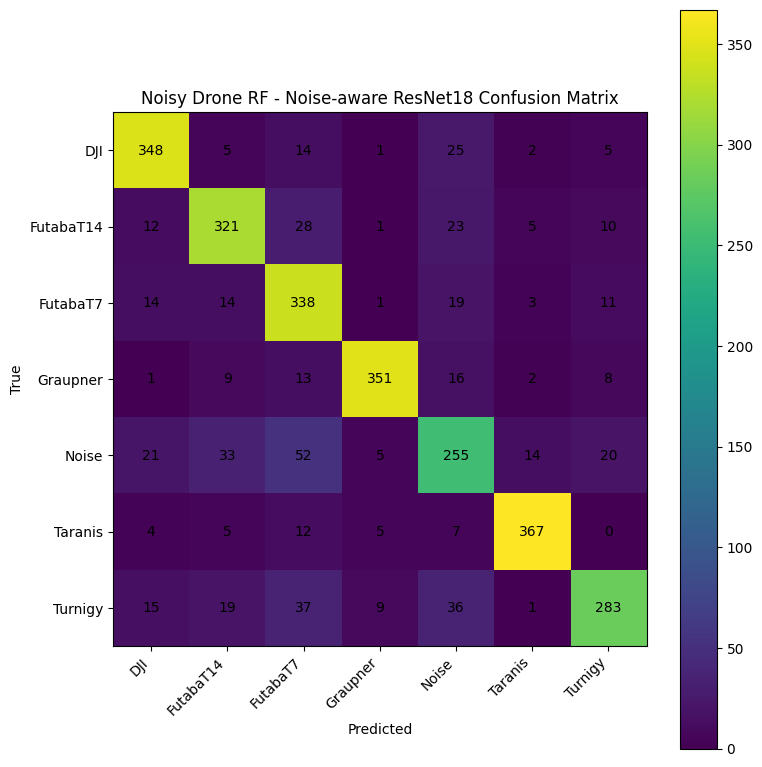

Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware/confusion_matrix_noise_aware.png


,SNR,accuracy
0,-20,0.186916
1,-18,0.329787
2,-16,0.417476
3,-14,0.571429
4,-12,0.637255
5,-10,0.720930
6,-8,0.788462
7,-6,0.862745
8,-4,0.877551
9,-2,0.877049


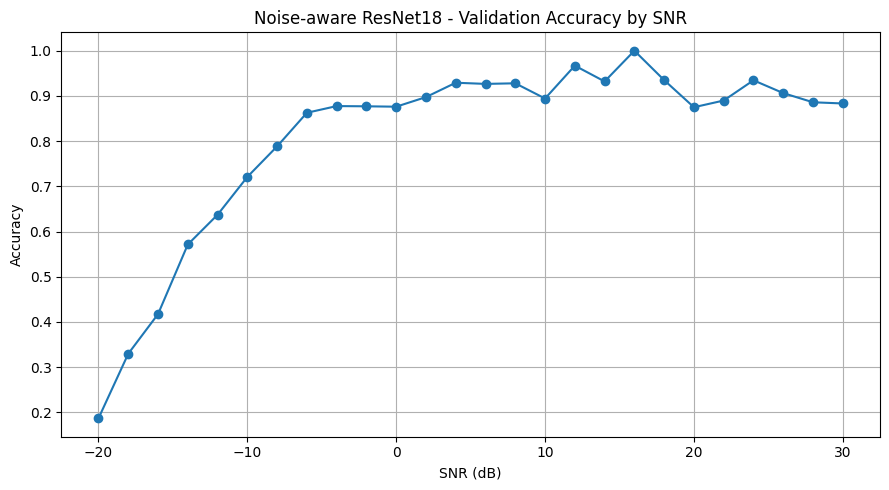

Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware/accuracy_by_snr_noise_aware.png


In [73]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

noise_aware_best_path = os.path.join(SAVE_DIR_NOISE_AWARE, "best_low_snr.pt")
# Alternative:
# noise_aware_best_path = os.path.join(SAVE_DIR_NOISE_AWARE, "best_overall.pt")

noise_aware_eval_model = ResNet18RFSpec(num_classes=len(class_names)).to(device)
noise_aware_eval_model.load_state_dict(torch.load(noise_aware_best_path, map_location=device))
noise_aware_eval_model.eval()

na_preds = []
na_labels = []
na_snrs = []

with torch.no_grad():
    for x, labels, snrs in valid_loader:
        x = x.to(device, non_blocking=True).float()
        labels = labels.to(device, non_blocking=True).long()
        outputs = noise_aware_eval_model(x)
        preds = outputs.argmax(dim=1)

        na_preds.extend(preds.cpu().numpy())
        na_labels.extend(labels.cpu().numpy())
        na_snrs.extend(snrs.cpu().numpy())

print("Loaded:", noise_aware_best_path)
print(classification_report(na_labels, na_preds, target_names=class_names, zero_division=0))

na_results_df = pd.DataFrame({
    "label": np.array(na_labels),
    "pred": np.array(na_preds),
    "snr": np.array(na_snrs),
})
na_results_df["correct"] = na_results_df["label"] == na_results_df["pred"]

overall_acc = na_results_df["correct"].mean()
print(f"Noise-aware overall validation accuracy: {overall_acc:.4f}")

# Overall confusion matrix
cm = confusion_matrix(na_labels, na_preds, labels=list(range(len(class_names))))
plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("Noisy Drone RF - Noise-aware ResNet18 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, int(cm[i, j]), ha="center", va="center")
plt.tight_layout()
na_cm_path = os.path.join(SAVE_DIR_NOISE_AWARE, "confusion_matrix_noise_aware.png")
plt.savefig(na_cm_path, dpi=200)
plt.show()
print("Saved:", na_cm_path)

# Accuracy by exact SNR
na_snr_acc = na_results_df.groupby("snr")["correct"].mean().reset_index()
na_snr_acc.columns = ["SNR", "accuracy"]
display(na_snr_acc)

plt.figure(figsize=(9, 5))
plt.plot(na_snr_acc["SNR"], na_snr_acc["accuracy"], marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Noise-aware ResNet18 - Validation Accuracy by SNR")
plt.grid(True)
plt.tight_layout()
na_snr_path = os.path.join(SAVE_DIR_NOISE_AWARE, "accuracy_by_snr_noise_aware.png")
plt.savefig(na_snr_path, dpi=200)
plt.show()
print("Saved:", na_snr_path)


## 21. Compare baseline vs noise-aware by SNR group

This cell compares the old baseline predictions against the new noise-aware predictions.

Expected behavior:

- Low-SNR accuracy should improve.
- Medium/high-SNR accuracy may stay similar or drop slightly.
- If low-SNR improves but high-SNR collapses, reduce the low-SNR weights in Section 18/19.


In [74]:
# Baseline results should exist from the earlier evaluation cell:
# all_labels, all_preds, all_snrs

baseline_results_df = pd.DataFrame({
    "label": np.array(all_labels),
    "pred": np.array(all_preds),
    "snr": np.array(all_snrs),
})
baseline_results_df["correct"] = baseline_results_df["label"] == baseline_results_df["pred"]

snr_groups = {
    "low_snr_-20_to_-10": (-20, -10),
    "medium_snr_-8_to_4": (-8, 4),
    "high_snr_6_to_30": (6, 30),
}

comparison_rows = []
for group_name, (snr_min, snr_max) in snr_groups.items():
    base_subset = baseline_results_df[(baseline_results_df["snr"] >= snr_min) & (baseline_results_df["snr"] <= snr_max)]
    na_subset = na_results_df[(na_results_df["snr"] >= snr_min) & (na_results_df["snr"] <= snr_max)]

    base_acc = base_subset["correct"].mean()
    na_acc = na_subset["correct"].mean()

    comparison_rows.append({
        "snr_group": group_name,
        "snr_min": snr_min,
        "snr_max": snr_max,
        "baseline_samples": len(base_subset),
        "noise_aware_samples": len(na_subset),
        "baseline_acc": base_acc,
        "noise_aware_acc": na_acc,
        "change": na_acc - base_acc,
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

comparison_path = os.path.join(SAVE_DIR_NOISE_AWARE, "baseline_vs_noise_aware_snr_group_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path)

# Also compare per-class recall by SNR group.
per_class_compare_rows = []
for group_name, (snr_min, snr_max) in snr_groups.items():
    base_subset = baseline_results_df[(baseline_results_df["snr"] >= snr_min) & (baseline_results_df["snr"] <= snr_max)]
    na_subset = na_results_df[(na_results_df["snr"] >= snr_min) & (na_results_df["snr"] <= snr_max)]

    for cls_id, cls_name in enumerate(class_names):
        base_cls = base_subset[base_subset["label"] == cls_id]
        na_cls = na_subset[na_subset["label"] == cls_id]

        base_recall = (base_cls["pred"] == cls_id).mean() if len(base_cls) else np.nan
        na_recall = (na_cls["pred"] == cls_id).mean() if len(na_cls) else np.nan

        per_class_compare_rows.append({
            "snr_group": group_name,
            "class": cls_name,
            "baseline_recall": base_recall,
            "noise_aware_recall": na_recall,
            "change": na_recall - base_recall,
        })

per_class_compare_df = pd.DataFrame(per_class_compare_rows)
display(per_class_compare_df)

per_class_compare_path = os.path.join(SAVE_DIR_NOISE_AWARE, "baseline_vs_noise_aware_per_class_recall.csv")
per_class_compare_df.to_csv(per_class_compare_path, index=False)
print("Saved:", per_class_compare_path)


,snr_group,snr_min,snr_max,baseline_samples,noise_aware_samples,baseline_acc,noise_aware_acc,change
0,low_snr_-20_to_-10,-20,-10,618,618,0.496764,0.474110,-0.022654
1,medium_snr_-8_to_4,-8,4,761,761,0.917214,0.873850,-0.043364
2,high_snr_6_to_30,6,30,1421,1421,0.952850,0.918367,-0.034483


Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware/baseline_vs_noise_aware_snr_group_comparison.csv


,snr_group,class,baseline_recall,noise_aware_recall,change
0,low_snr_-20_to_-10,DJI,0.345679,0.493827,0.148148
1,low_snr_-20_to_-10,FutabaT14,0.227273,0.284091,0.056818
2,low_snr_-20_to_-10,FutabaT7,0.409091,0.465909,0.056818
3,low_snr_-20_to_-10,Graupner,0.609195,0.540230,-0.068966
4,low_snr_-20_to_-10,Noise,0.781609,0.620690,-0.160920
5,low_snr_-20_to_-10,Taranis,0.627907,0.662791,0.034884
6,low_snr_-20_to_-10,Turnigy,0.475248,0.287129,-0.188119
7,medium_snr_-8_to_4,DJI,0.901786,0.910714,0.008929
8,medium_snr_-8_to_4,FutabaT14,0.883929,0.901786,0.017857
9,medium_snr_-8_to_4,FutabaT7,0.943396,0.915094,-0.028302


Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware/baseline_vs_noise_aware_per_class_recall.csv


## 22. Noise-aware confusion matrices by SNR group

These matrices should be compared with the baseline SNR-group confusion matrices.

The most important question is whether low-SNR drone/controller samples are still being over-predicted as `Noise`.


Noise-aware low_snr_-20_to_-10: SNR -20 to -10 dB
Samples: 618
Accuracy: 0.4741
              precision    recall  f1-score   support

         DJI       0.50      0.49      0.50        81
   FutabaT14       0.36      0.28      0.32        88
    FutabaT7       0.32      0.47      0.38        88
    Graupner       0.89      0.54      0.67        87
       Noise       0.34      0.62      0.44        87
     Taranis       0.86      0.66      0.75        86
     Turnigy       0.47      0.29      0.36       101

    accuracy                           0.47       618
   macro avg       0.53      0.48      0.49       618
weighted avg       0.53      0.47      0.48       618



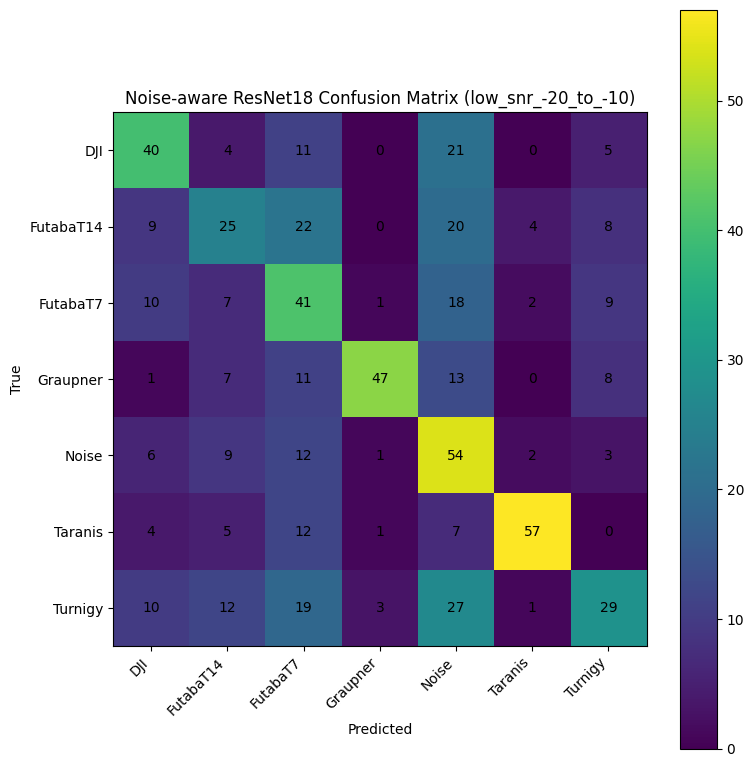

Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware/confusion_matrix_noise_aware_low_snr_-20_to_-10.png
Noise-aware medium_snr_-8_to_4: SNR -8 to 4 dB
Samples: 761
Accuracy: 0.8739
              precision    recall  f1-score   support

         DJI       0.89      0.91      0.90       112
   FutabaT14       0.87      0.90      0.89       112
    FutabaT7       0.75      0.92      0.83       106
    Graupner       0.97      0.96      0.96       119
       Noise       0.83      0.69      0.75       104
     Taranis       0.91      0.99      0.95       111
     Turnigy       0.91      0.71      0.80        97

    accuracy                           0.87       761
   macro avg       0.88      0.87      0.87       761
weighted avg       0.88      0.87      0.87       761



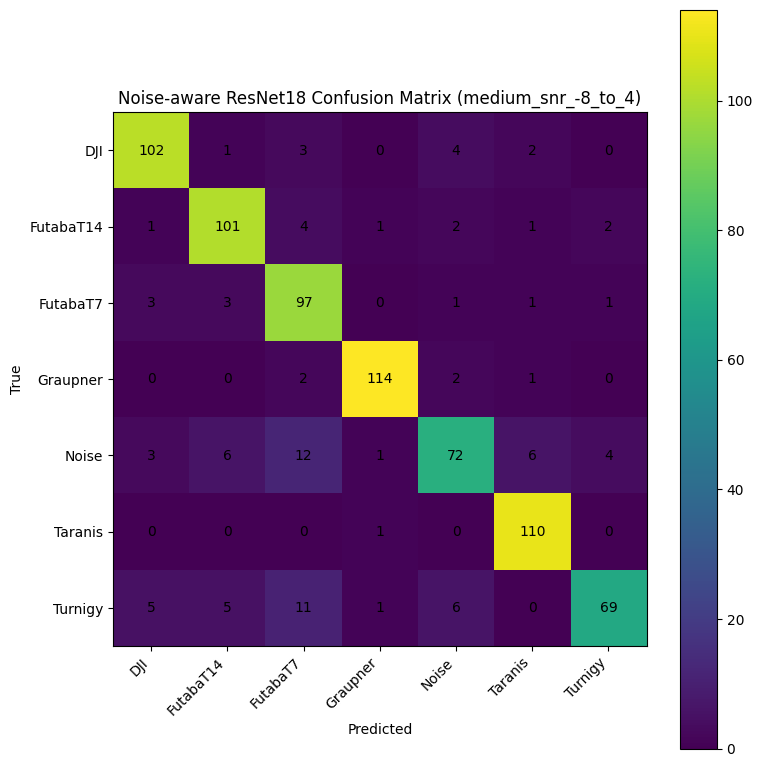

Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware/confusion_matrix_noise_aware_medium_snr_-8_to_4.png
Noise-aware high_snr_6_to_30: SNR 6 to 30 dB
Samples: 1421
Accuracy: 0.9184
              precision    recall  f1-score   support

         DJI       0.93      1.00      0.96       207
   FutabaT14       0.88      0.97      0.93       200
    FutabaT7       0.84      0.97      0.90       206
    Graupner       0.94      0.98      0.96       194
       Noise       0.96      0.62      0.75       209
     Taranis       0.97      0.99      0.98       203
     Turnigy       0.93      0.92      0.92       202

    accuracy                           0.92      1421
   macro avg       0.92      0.92      0.91      1421
weighted avg       0.92      0.92      0.91      1421



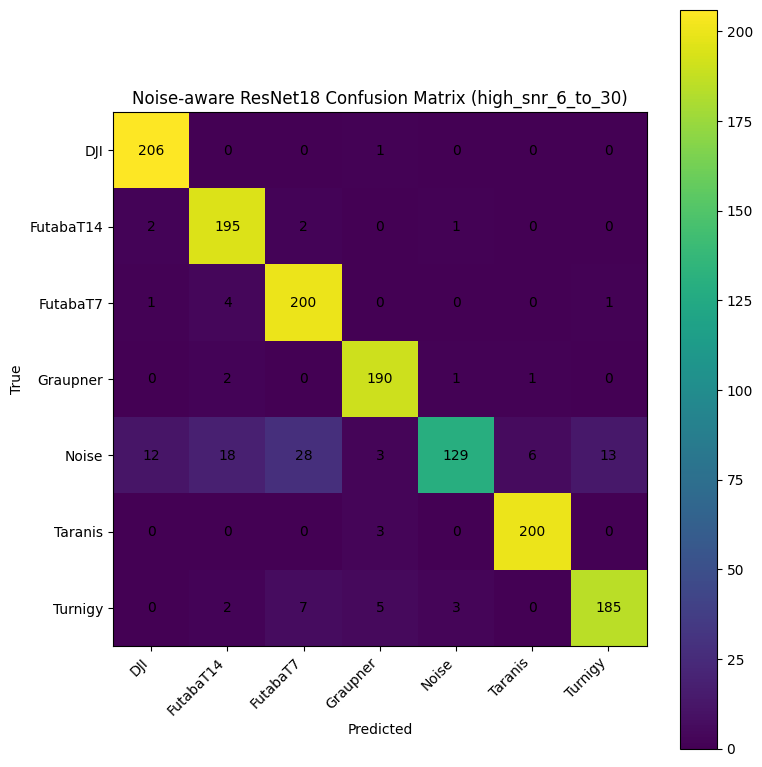

Saved: /content/drive/MyDrive/RFUAV_Project/models/noisy_drone_resnet18_spec_balanced_noise_aware/confusion_matrix_noise_aware_high_snr_6_to_30.png


In [75]:
def plot_cm_from_results(df, title, save_path):
    labels = list(range(len(class_names)))
    cm = confusion_matrix(df["label"], df["pred"], labels=labels)

    plt.figure(figsize=(8, 8))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(np.arange(len(class_names)), class_names)
    plt.colorbar()

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()
    return cm

for group_name, (snr_min, snr_max) in snr_groups.items():
    subset = na_results_df[(na_results_df["snr"] >= snr_min) & (na_results_df["snr"] <= snr_max)].copy()
    acc = subset["correct"].mean()
    print("=" * 80)
    print(f"Noise-aware {group_name}: SNR {snr_min} to {snr_max} dB")
    print(f"Samples: {len(subset)}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(
        subset["label"], subset["pred"],
        labels=list(range(len(class_names))),
        target_names=class_names,
        zero_division=0,
    ))

    save_path = os.path.join(SAVE_DIR_NOISE_AWARE, f"confusion_matrix_noise_aware_{group_name}.png")
    plot_cm_from_results(
        subset,
        f"Noise-aware ResNet18 Confusion Matrix ({group_name})",
        save_path,
    )
    print("Saved:", save_path)
